# Bayes theorem

## **Bayes Theorem**

Bayes' theorem is a mathematical principle used to calculate the conditional probability of an event given some evidence related to that event. It establishes a relationship between the probability of an event and prior knowledge of conditions associated with it. As evidence accumulates, the probability of the event can be determined more accurately.

$$ P(A|B) = \frac{P(B|A)P(A)}{P(B)} $$

- $P(A|B)$, also known as the posterior probability, represents the probability of the hypothesis being true given the available data.
  
- $P(B|A)$ is the probability of obtaining the evidence given the hypothesis.
  
- $P(A)$ is the prior probability, representing the probability of the hypothesis being true before any data is considered.
  
- $P(B)$ is the general probability of occurrence of the evidence, without any hypothesis, also known as the normalizing constant.

**Example: Fire and Smoke**

Suppose we want to find the probability of a fire given that there is smoke:

$$P(Fire|Smoke) =\frac {P(Smoke|Fire) * P(Fire)}{P(Smoke)}$$

Here,
- $P(Fire)$ is the Prior
- $P(Smoke|Fire)$ is the Likelihood
- $P(Smoke)$ is the evidence

**Example:**

Let's consider a scenario where an individual tests positive for an illness. This particular illness affects approximately 1.2% of the population at any given time. The diagnostic test for this illness has an accuracy of 85% for individuals who actually have the illness and 97% for those who do not.

Now, let's define the events involved:

- $A$: The individual has the illness, also known as the hypothesis.
- $\overline{A}$: The individual does not have the illness.
- $B$: The individual tests positive for the illness, also referred to as the evidence.
- $P(A|B)$: The probability that the individual has the illness given a positive test result, known as the posterior probability, which is what we aim to calculate.
- $P(B|A)$: The probability that the individual tests positive given that they have the illness, which is 0.85 according to the test's accuracy.
- $P(A)$: The prior probability or the likelihood of the individual having the illness without any evidence, which is 0.012 based on the prevalence of the illness in the population.
- $P(B)$: The probability that the individual tests positive for the illness. This can be computed in two ways:

    - True Positive (individual has the illness and tests positive): $P(B|A)*P(A)=0.85*0.012=0.0102.$
    - False Positive (individual does not have the illness but tests positive due to test inaccuracy): $P(B|\overline{A})*P(\overline{A})=(1-0.97)*(1-0.012)=0.02964.$
    
    Here, $P(B|\overline{A})$ represents the probability of a positive test result for an individual who does not have the illness, indicating the test's inaccuracy for those without the illness.
    
    Additionally, $P(\overline{A})$ denotes the probability that the individual does not have the illness, which is derived from the complement of the illness prevalence.
    
    Hence, $P(B)$, the denominator in Bayes' theorem, is the sum of these two probabilities:
    
    $P(B)= (P(B|A)*P(A)) + (P(B|\overline{A})*P(\overline{A}))=0.0102+0.2964=0.03984$.
    
    We can now compute the final answer using Bayes' theorem formula:
    
    $P(A|B)=P(B|A)*P(A)/P(B) =0.85*0.012 / 0.03984 = 0.256$.
    
    Thus, even with a positive medical test, the individual only has a 25.6% chance of actually suffering from the illness.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Given
P_ill              = 0.012   # prevalence
P_pos_given_ill    = 0.85    # sensitivity
P_pos_given_healthy = 0.03   # false-positive rate (1 - specificity)
P_healthy          = 1 - P_ill

# Law of Total Probability
P_pos = P_pos_given_ill * P_ill + P_pos_given_healthy * P_healthy

# Bayes' Theorem
P_ill_given_pos = (P_pos_given_ill * P_ill) / P_pos

print('BAYES THEOREM - MEDICAL TEST EXAMPLE')
print('=' * 45)
print(f'Prior P(ill)                  = {P_ill:.1%}')
print(f'Sensitivity P(+|ill)          = {P_pos_given_ill:.0%}')
print(f'False-positive rate P(+|hlthy)= {P_pos_given_healthy:.0%}')
print()
print(f'P(positive) [total prob.]     = {P_pos:.5f}')
print()
print(f'Posterior P(ill | +test)      = {P_ill_given_pos:.4f}  ({P_ill_given_pos:.1%})')
print('=' * 45)
print()
print(f'Despite a positive test, only ~{P_ill_given_pos:.0%} chance of actually being ill.')
print('Low prevalence (1.2%) overwhelms even a moderately accurate test — base-rate neglect.')


BAYES THEOREM - MEDICAL TEST EXAMPLE
Prior P(ill)                  = 1.2%
Sensitivity P(+|ill)          = 85%
False-positive rate P(+|hlthy)= 3%

P(positive) [total prob.]     = 0.03984

Posterior P(ill | +test)      = 0.2560  (25.6%)

Despite a positive test, only ~26% chance of actually being ill.
Low prevalence (1.2%) overwhelms even a moderately accurate test — base-rate neglect.


### Prior vs Posterior — Visualisation

A positive test dramatically updates our belief, yet because the disease is rare
the posterior (~25.6%) is still far below 100%.

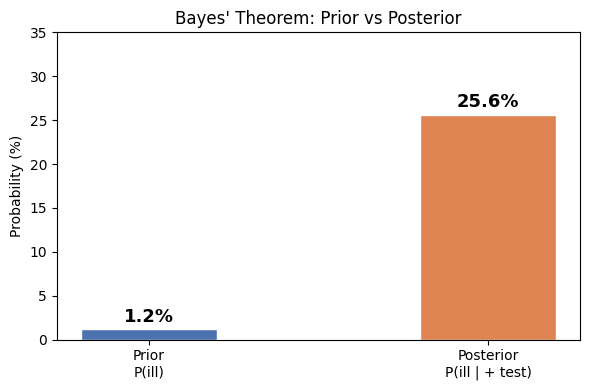

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Prior\nP(ill)', 'Posterior\nP(ill | + test)']
probs  = [P_ill, P_ill_given_pos]
colors = ['#4c72b0', '#dd8452']
bars   = ax.bar(labels, [p * 100 for p in probs], color=colors, width=0.4, edgecolor='white')
for bar, prob in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{prob:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_ylabel('Probability (%)')
ax.set_title("Bayes' Theorem: Prior vs Posterior")
ax.set_ylim(0, 35)
plt.tight_layout()
plt.show()


---
## ML/AI Connection

- **Naive Bayes** is Bayes' theorem applied to classification: posterior class probability is proportional to prior × likelihood.
- **Bayesian neural networks** place prior distributions over weights and compute a posterior after seeing data — giving uncertainty estimates on predictions.
- **Spam filtering:** early email spam filters (SpamAssassin) applied Bayes' theorem directly — $P(\text{spam}|\text{words})$.
- **Posterior = prior × likelihood** is the mathematical foundation of Bayesian deep learning and probabilistic programming (PyMC, Pyro, Stan).
